Try cuda-graph end-to-end model

In [1]:
import torch
from torch import nn
from model import Transformer, ModelArgs, Linear, ParallelEmbedding, Gate

from static_moe import dynamic_moe_to_static

In [2]:
# https://docs.pytorch.org/docs/stable/notes/numerical_accuracy.html
torch.backends.cudnn.allow_tf32 = False
torch.backends.cuda.matmul.allow_fp16_reduced_precision_reduction = False
torch.backends.cuda.matmul.allow_bf16_reduced_precision_reduction = False

In [3]:
device = "cuda:0"
torch.cuda.set_device(device)

# NOTE: use higher precision to see if precision problem persists
# difference between static vs dynamic MoE gets very large when using bfloat16 or even float32
dtype = torch.float64
torch.set_default_dtype(dtype)
torch.set_num_threads(8)
torch.manual_seed(965)

In [4]:
def report_memory():
    print(
        f"Allocated: {torch.cuda.memory_allocated() / 1024 ** 3:.2f} GB, "
        f"Reserved: {torch.cuda.memory_reserved() / 1024 ** 3:.2f} GB, "
        f"Max Allocated: {torch.cuda.max_memory_allocated() / 1024 ** 3:.2f} GB, "
        f"Max Reserved: {torch.cuda.max_memory_reserved() / 1024 ** 3:.2f} GB"
    )

report_memory()

Allocated: 0.00 GB, Reserved: 0.00 GB, Max Allocated: 0.00 GB, Max Reserved: 0.00 GB


In [5]:
# small size for fast on-device test
args = ModelArgs(
    vocab_size=32000,
    dim=512,
    inter_dim=2736,
    moe_inter_dim=352,
    n_layers=20,
    n_dense_layers=1,
    n_routed_experts=16,
    n_shared_experts=2,
    n_activated_experts=6,
)
args

ModelArgs(max_batch_size=8, max_seq_len=16384, dtype='bf16', vocab_size=32000, dim=512, inter_dim=2736, moe_inter_dim=352, n_layers=20, n_dense_layers=1, n_heads=16, n_routed_experts=16, n_shared_experts=2, n_activated_experts=6, n_expert_groups=1, n_limited_groups=1, score_func='softmax', route_scale=1.0, q_lora_rank=0, kv_lora_rank=512, qk_nope_head_dim=128, qk_rope_head_dim=64, v_head_dim=128, original_seq_len=4096, rope_theta=10000.0, rope_factor=40, beta_fast=32, beta_slow=1, mscale=1.0)

In [6]:
with torch.device(device):
    model = Transformer(args)

# model

In [7]:
report_memory()

Allocated: 13.72 GB, Reserved: 13.74 GB, Max Allocated: 13.73 GB, Max Reserved: 13.74 GB


In [8]:
model.layers[0].ffn.w1.weight  # weight not initialized!

Parameter containing:
tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]], device='cuda:0', requires_grad=True)

In [9]:
def init_weights_normal(m):
    if isinstance(m, (Linear, ParallelEmbedding, Gate)):
        nn.init.normal_(m.weight, mean=0.0, std=0.1)

model.apply(init_weights_normal);

In [10]:
model.layers[0].ffn.w1.weight  # initialized to random weights

Parameter containing:
tensor([[-0.1140,  0.1583, -0.0698,  ...,  0.0168,  0.0056, -0.0905],
        [ 0.0469,  0.2350,  0.0286,  ...,  0.1755,  0.2062,  0.0779],
        [ 0.1642,  0.0704, -0.1980,  ..., -0.2891, -0.0235, -0.0330],
        ...,
        [-0.0474,  0.0383, -0.0147,  ...,  0.0604,  0.1139, -0.0084],
        [-0.0519, -0.2447,  0.0199,  ...,  0.0218, -0.1062, -0.1248],
        [-0.1571, -0.1162, -0.1993,  ...,  0.0371,  0.0801,  0.1215]],
       device='cuda:0', requires_grad=True)

In [11]:
model.embed.weight

Parameter containing:
tensor([[ 0.1075,  0.0220,  0.0309,  ...,  0.1581, -0.0221, -0.0721],
        [-0.0694, -0.0231,  0.1256,  ..., -0.0678,  0.0106,  0.0284],
        [ 0.0763,  0.0376, -0.0213,  ..., -0.1038,  0.0295, -0.0630],
        ...,
        [ 0.0525,  0.0555, -0.0465,  ..., -0.0808,  0.0316, -0.0278],
        [ 0.0362, -0.0229, -0.0098,  ..., -0.0472, -0.0080,  0.1124],
        [ 0.1297,  0.0907, -0.0599,  ..., -0.2064, -0.0660, -0.1823]],
       device='cuda:0', requires_grad=True)

In [12]:
batch = 4
num_tokens = 50
tokens = torch.randint(0, args.vocab_size, size=(batch, num_tokens), dtype=torch.int64).to(device)
output = model.forward(tokens)
print(f"output.shape = {output.shape}")
print(f"output.min = {output.min()}, output.max = {output.max()}")

output.shape = torch.Size([4, 50, 32000])
output.min = -12.571207959123573, output.max = 11.246902924406745


In [13]:
import matplotlib.pyplot as plt
# plt.hist(output.flatten().to(torch.float32).cpu(), bins=50);  # look quite normal

## Replace dynamic MoE with static

In [14]:
for i in range(args.n_dense_layers, args.n_layers):
    model.layers[i].ffn = dynamic_moe_to_static(args, model.layers[i].ffn, device=device)

In [15]:
output_static = model.forward(tokens)
print(f"output_static.shape = {output_static.shape}")
print(f"output_static.min = {output_static.min()}, output_static.max = {output_static.max()}")

output_static.shape = torch.Size([4, 50, 32000])
output_static.min = -12.571207959123575, output_static.max = 11.246902924406756


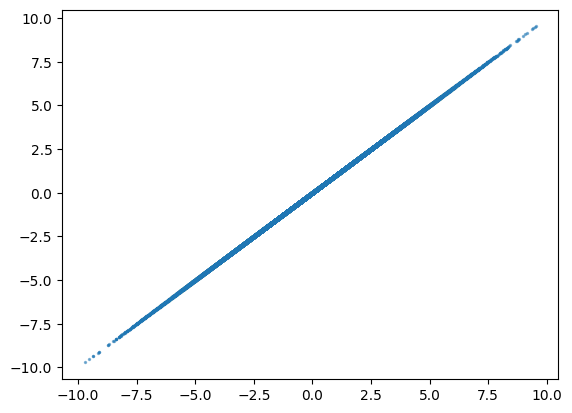

In [16]:
pos = -1  # error is largest at the last position
plt.scatter(
    output_static[:,pos,:].to(torch.float32).cpu().flatten(),
    output[:,pos,:].to(torch.float32).cpu().flatten(),
    s=2, alpha=0.5
)
# why error so large when using many layers and bfloat16?

In [17]:
absdiff_static = torch.abs(output_static - output).to(torch.float32).cpu()

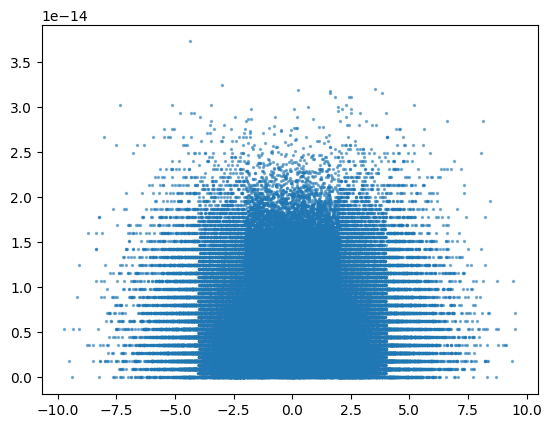

In [18]:
plt.scatter(
    output[:,pos,:].to(torch.float32).cpu().flatten(),
    absdiff_static[:,pos,:].flatten(),
    s=2, alpha=0.5
)

In [19]:
print("mean & max abs error: ", float(absdiff_static.mean()), float(absdiff_static.max()))

mean & max abs error:  5.82851883686804e-15 4.263256414560601e-14


In [20]:
# torch.testing.assert_close(output_static, output, rtol=0.05, atol=0.3)

## test torch.compile

In [21]:
def compile_model(model):
    model.compute_all_layers = torch.compile(
        model.compute_all_layers,
        backend="cudagraphs",
        dynamic=False,
        fullgraph=True
    )
    # in-place change

In [22]:
compile_model(model)

In [23]:
output_compiled = model.forward(tokens)

In [24]:
print(f"output_compiled.shape = {output_compiled.shape}")
print(f"output_compiled.min = {output_compiled.min()}, output_compiled.max = {output_compiled.max()}")

output_compiled.shape = torch.Size([4, 50, 32000])
output_compiled.min = -12.571207959123575, output_compiled.max = 11.246902924406756


In [25]:
torch.testing.assert_close(output_static, output_compiled, rtol=1e-4, atol=1e-4)

In [26]:
torch.equal(output_static, output_compiled)
# output_static - output_compiled  # all zeros

True

## profiler trace

In [27]:
def torch_profiler(log_dir):
    return torch.profiler.profile(
        on_trace_ready=torch.profiler.tensorboard_trace_handler(log_dir),
        activities=[torch.profiler.ProfilerActivity.CPU, torch.profiler.ProfilerActivity.CUDA],
        record_shapes=True,
        profile_memory=True,
        with_flops=True,
        with_stack=True
        )

with torch_profiler('./profile_trace/compile_ds_block'):
    torch.compiler.cudagraph_mark_step_begin()
    output_compiled = model.forward(tokens)